In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Spark_MLlib_AnswerKey") \
    .getOrCreate()

# Đường dẫn gốc trên HDFS (Thay đổi theo thực tế của hệ thống cài đặt)
HDFS_PATH = "hdfs://localhost:9000/user/data/SQLdata/"

In [2]:
df_cancer = spark.read.csv(HDFS_PATH + "breast-cancer.csv", header=True, inferSchema=True)

Tiền xử lý

In [3]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql.functions import col, when

df_cancer = df_cancer.drop("id")
indexer = StringIndexer(inputCol="diagnosis", outputCol="label")
df_cancer = indexer.fit(df_cancer).transform(df_cancer)
feature_cols_cancer = [c for c in df_cancer.columns if c not in ['diagnosis', 'label']]
assembler_cancer = VectorAssembler(inputCols=feature_cols_cancer, outputCol="features", handleInvalid="skip")
df_cancer = assembler_cancer.transform(df_cancer)

# convert values M/B in column Diagnosis to 0/1
df_cancer = df_cancer.withColumn(
 "diagnosis",
 when(col('diagnosis') == "B", 0)
 .when(col("diagnosis") == "M", 1)
 .otherwise(None)
)

In [4]:
from pyspark.ml.classification import LinearSVC
train_cancer, test_cancer = df_cancer.randomSplit([0.8, 0.2], seed=42)
svc = LinearSVC(featuresCol="features", labelCol="label", maxIter=50)
svc_model = svc.fit(train_cancer)

In [6]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix
predictions_cancer = svc_model.transform(test_cancer)
# Tính toán các tiêu chí
eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
eval_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
eval_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
eval_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
print("--- ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI KHỐI U ---")
print(f"Accuracy : {eval_acc.evaluate(predictions_cancer):.4f}")
print(f"F1-Score : {eval_f1.evaluate(predictions_cancer):.4f}")
print(f"Precision : {eval_prec.evaluate(predictions_cancer):.4f}")
print(f"Recall : {eval_rec.evaluate(predictions_cancer):.4f}")
print("-----------------------------------------")

--- ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI KHỐI U ---
Accuracy : 0.9651
F1-Score : 0.9650
Precision : 0.9652
Recall : 0.9651
-----------------------------------------


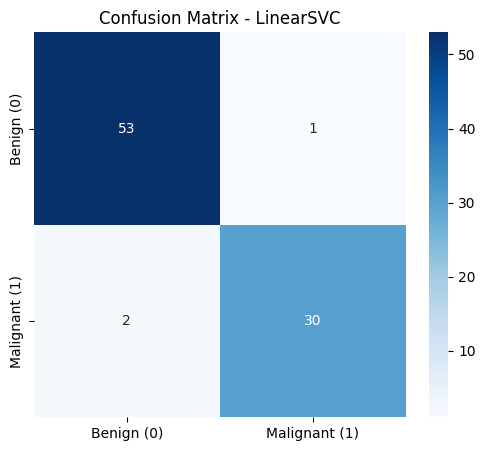

In [7]:
y_true_cancer = predictions_cancer.select("label").toPandas()
y_pred_cancer = predictions_cancer.select("prediction").toPandas()
cm_cancer = confusion_matrix(y_true_cancer, y_pred_cancer)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cancer, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)',
'Malignant (1)'])
plt.title("Confusion Matrix - LinearSVC")
plt.show()